# Principal Component Analysis (PCA) Demonstration In Python
#### Using Athletics Data

## Background
- Data on national athletics records for various countries is available.

- Data Source: Applied Multivariate Statistical Analysis by Richard A. Johnson , Dean W. Wichern

- Sample size is 55 countries' athletics  records for 8  different athletics events – 100 meters to Marathon

## Objective: 
- To  achieve data reduction and obtain scores for each country which can be used to rank countries based on athletics records.


## Data Description

| Column Name     | Description                                      |
|-----------------|--------------------------------------------------|
| 100m_s          | Time taken to complete 100 meters (seconds)     |
| 200m_s          | Time taken to complete 200 meters (seconds)     |
| 400m_s          | Time taken to complete 400 meters (seconds)     |
| 800m_min        | Time taken to complete 800 meters (minutes)     |
| 1500m_min       | Time taken to complete 1500 meters (minutes)    |
| 5000m_min       | Time taken to complete 5000 meters (minutes)    |
| 10000m_min      | Time taken to complete 10000 meters (minutes)   |
| Marathon_min   | Time taken to complete a marathon (minutes)     |


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data

In [2]:
athletics_df = pd.read_csv('Athleticsdata.csv')
#Drop categorical column
athletics = athletics_df.drop(columns=['Country'])
athletics.head()

,100m_s,200m_s,400m_s,800m_min,1500m_min,5000m_min,10000m_min,Marathon_min
0,10.39,20.81,46.84,1.81,3.70,14.04,29.36,137.72
1,10.31,20.06,44.84,1.74,3.57,13.28,27.66,128.30
2,10.44,20.81,46.82,1.79,3.60,13.26,27.72,135.90
3,10.34,20.68,45.04,1.73,3.60,13.22,27.45,129.95
4,10.28,20.58,45.91,1.80,3.75,14.68,30.55,146.62


### Scale Data

Scaling is required in PCA because it is variance-based; without scaling, features with larger units or ranges dominate the principal components, biasing the results

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(athletics)
X = pd.DataFrame(X_scaled, columns=athletics.columns)
X.head()

,100m_s,200m_s,400m_s,800m_min,1500m_min,5000m_min,10000m_min,Marathon_min
0,-0.227911,-0.204089,0.277945,0.265078,0.011769,0.244610,0.207070,0.119876
1,-0.457388,-1.378238,-1.107373,-0.844216,-0.829733,-0.712758,-0.742002,-0.910447
2,-0.084489,-0.204089,0.264092,-0.051863,-0.635540,-0.737951,-0.708506,-0.079188
3,-0.371334,-0.407608,-0.968841,-1.002686,-0.635540,-0.788339,-0.859241,-0.729976
4,-0.543441,-0.564161,-0.366228,0.106607,0.335424,1.050814,0.871421,1.093323


### Perform PCA

In [4]:
pca = PCA()
pca.fit(X)

PCA()

### Proportion Of Explained Variance

In [5]:
eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
pca_summary = pd.DataFrame({
    'Standard Deviation': np.sqrt(eigenvalues),
    'Proportion of Variance': explained_variance_ratio,
    'Cumulative Proportion': cumulative_variance
}, index=[f'PC{i+1}' for i in range(len(eigenvalues))])
pca_summary

,Standard Deviation,Proportion of Variance,Cumulative Proportion
PC1,2.597793,0.828228,0.828228
PC2,0.944123,0.109395,0.937624
PC3,0.401877,0.019821,0.957445
PC4,0.355441,0.015505,0.972950
PC5,0.285470,0.010001,0.982951
PC6,0.262701,0.008470,0.991421
PC7,0.216828,0.005770,0.997191
PC8,0.151291,0.002809,1.000000


### Observations :
- PC1 alone explains ~83% of the variance, indicating a single dominant underlying factor (overall athletic performance) across all events.

- First two PCs explain ~94% of the variance, so the data can be effectively reduced to 2 dimensions with minimal information loss.

### Loadings

Loadings are the correlations (weights) between the original variables and each principal component, showing how much each variable contributes to a component.

In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=athletics.columns,
    columns=[f'PC{i+1}' for i in range(len(athletics.columns))]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
100m_s,0.318293,0.564684,-0.326323,0.128698,0.267423,-0.590449,0.154303,-0.113210
200m_s,0.336855,0.462270,-0.369020,-0.256689,-0.157078,0.647587,-0.128066,0.101621
400m_s,0.355561,0.249318,0.561085,0.649891,-0.221457,0.158447,-0.009292,0.002585
800m_min,0.368626,0.013405,0.530948,-0.481745,0.540354,-0.011856,-0.237073,0.040305
1500m_min,0.372682,-0.140200,0.154640,-0.406710,-0.490808,-0.143104,0.608456,-0.143305
5000m_min,0.364283,-0.312458,-0.189618,0.030521,-0.250168,-0.155079,-0.592691,-0.543015
10000m_min,0.366702,-0.307018,-0.181817,0.081362,-0.128320,-0.231701,-0.165205,0.796334
Marathon_min,0.341825,-0.439947,-0.260172,0.300243,0.492792,0.329455,0.393327,-0.160236


### Observation :
First Principal Component can be interpreted as ‘general athletics skill’ since all variables have similar loadings.

### Scree Plot

A scree plot shows the variance explained by each principal component, helping decide how many components to retain by identifying where the explained variance starts to level off (the “elbow”).

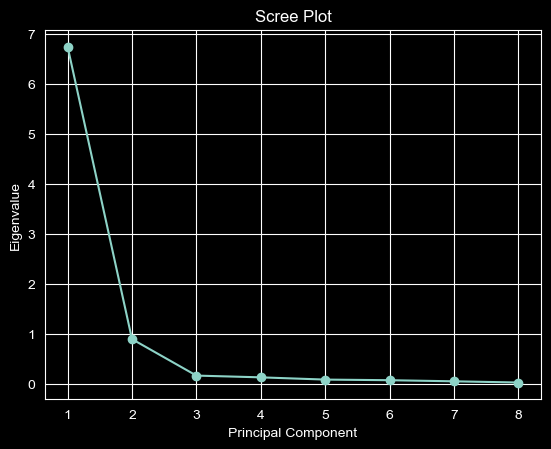

In [7]:
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

### Observations :

- PC1 is sufficient because it captures the vast majority of the variance, and the scree plot shows a clear elbow after PC1, with remaining components contributing negligibly.

### PCA Scores

In [8]:
scores = pca.transform(X)
scores_df = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(scores.shape[1])])
athletics_df['Performance'] = scores_df['PC1']
athletics_df.sort_values('Performance').head()

,Country,100m_s,200m_s,400m_s,800m_min,1500m_min,5000m_min,10000m_min,Marathon_min,Performance
52,USA,9.93,19.75,43.86,1.73,3.53,13.20,27.43,128.22,-3.460450
20,Great Britain and Northern Ireland,10.11,20.21,44.93,1.70,3.51,13.01,27.51,129.13,-3.050287
28,Italy,10.01,19.72,45.26,1.73,3.60,13.23,27.52,131.08,-2.750446
53,USSR,10.07,20.00,44.60,1.75,3.59,13.20,27.53,130.55,-2.649378
18,German Democratic Republic,10.12,20.33,44.87,1.73,3.56,13.17,27.42,129.92,-2.612248


### Observation :
USA is the top performing country (smaller score is better athletics performance)

### Verification: Correlation of PCs

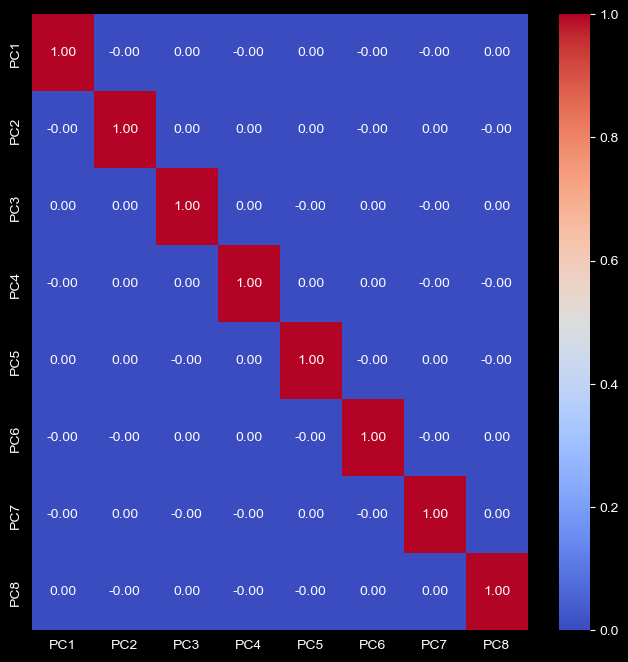

In [9]:
plt.figure(figsize=(8, 8))
scores_corr = scores_df.corr()
sns.heatmap(scores_corr,annot=True,fmt=".2f",cmap="coolwarm",annot_kws={"size": 10})
plt.show()